# **Using mean or median**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.impute  import SimpleImputer
from sklearn.compose import ColumnTransformer

In [7]:
df = pd.read_csv('train.csv')

In [8]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
df['Family'] = df['SibSp'] + df['Parch']

In [10]:
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Family
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1


In [11]:
df = df[['Age','Fare','Family','Survived']]
# Use double square brackets to select multiple columns in a pandas DataFrame.

In [12]:
df.head(2)

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1


In [13]:
df['Fare'] = [x if (pd.notna(x) and x >= 10) else None for x in df['Fare']]

<ipython-input-13-cb9f3ae3b3a1>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Fare'] = [x if (pd.notna(x) and x >= 10) else None for x in df['Fare']]


In [14]:
df.head()

,Age,Fare,Family,Survived
0,22.0,NaN,1,0
1,38.0,71.2833,1,1
2,26.0,NaN,0,1
3,35.0,53.1000,1,1
4,35.0,NaN,0,0


In [15]:
df.isnull().mean()

,0
Age,0.198653
Fare,0.377104
Family,0.000000
Survived,0.000000


In [16]:
df.describe()

,Age,Fare,Family,Survived
count,714.000000,555.000000,891.000000,891.000000
mean,29.699118,47.151223,0.904602,0.383838
std,14.526497,58.066884,1.613459,0.486592
min,0.420000,10.170800,0.000000,0.000000
25%,20.125000,15.645850,0.000000,0.000000
50%,28.000000,26.550000,0.000000,0.000000
75%,38.000000,55.220850,1.000000,1.000000
max,80.000000,512.329200,10.000000,1.000000


In [17]:
df.isnull().sum()

,0
Age,177
Fare,336
Family,0
Survived,0


There are two strategies:
 * Uni Variate Imputation
 * Multi Variate Imputation

 If we have multiple columns, among which there is a column (x) with missing values and I am using values from the same column (x) to handle missing values is called uni variate analysis.

 Whereas if i am using other columns to fill missing value in x, is called multi variate analysis.

# Case- 01 : Substituting with mean / median:
-> If data is normally distributed/ symmetric use mean

-> If skewed, use median

Benefit:
* Easy to implement.
* Good for small data

Disadvantage:
* Change the shape of  distribution, if replace with mean.
* Start counting some values as outliers,even though they are not.
* Changes in covariance/ co relationship.

When to use:
* Data is MCAR
* 5% of data is missing.

# Using Pandas:

In [18]:
x = df.drop(columns=['Survived'])
y = df['Survived']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [20]:
X_train.shape, X_test.shape

((712, 3), (179, 3))

In [21]:
#Creating variables to hold mean/ median values
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

mean_fare = X_train['Fare'].mean()
median_fare = X_train['Fare'].median()

In [22]:
#Creating 4 new col, in each col replacing missing value with the four variables created:
X_train['Age_median'] = X_train['Age'].fillna(median_age)
X_train['Age_mean'] = X_train['Age'].fillna(mean_age)

X_train['Fare_median'] = X_train['Fare'].fillna(median_fare)
X_train['Fare_mean'] = X_train['Fare'].fillna(mean_fare)

In [23]:
X_train.sample(3)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
461,34.0,NaN,0,34.00,34.000000,26.55,46.863829
77,NaN,NaN,0,28.75,29.785904,26.55,46.863829
640,20.0,NaN,0,20.00,20.000000,26.55,46.863829


In [24]:
print('Orignal age variable variance:', X_train['Age'].var())
print("Age median variable variance", X_train['Age_median'].var())
print("Age mean variable variance", X_train['Age_mean'].var())

print("Orignal Fare variable variance", X_train['Fare'].var())
print("Fare median variable variance", X_train['Fare_median'].var())
print("Fare mean variable variance", X_train['Fare_mean'].var())

Orignal age variable variance: 204.3495133904614
Age median variable variance 161.9895663346054
Age mean variable variance 161.81262452718673
Orignal Fare variable variance 3191.154154255104
Fare median variable variance 2102.661672452332
Fare mean variable variance 2006.2530336878056


* Since there were around 37% missing data in fare, there are more drastic changes in it as compared to age.

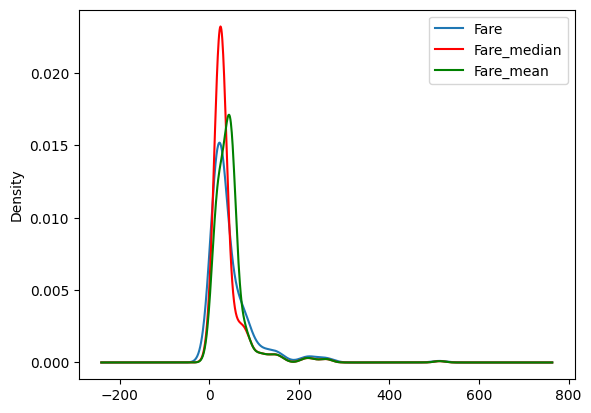

In [27]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111)
#orignal variable dis
X_train['Fare'].plot(kind = 'kde',ax = ax)
#variable imputed with median
X_train['Fare_median'].plot(kind = 'kde',ax = ax,color = 'red')
#variable imputed with mean
X_train['Fare_mean'].plot(kind = 'kde',ax = ax,color = 'green')

#add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines,labels,loc = 'best')


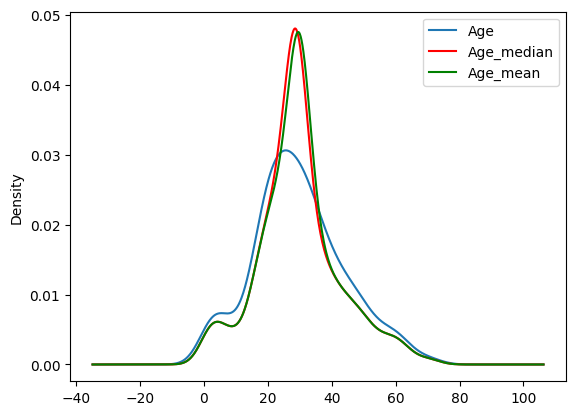

In [30]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111)
#orignal variable dis
X_train['Age'].plot(kind = 'kde',ax = ax)
#variable imputed with median
X_train['Age_median'].plot(kind = 'kde',ax = ax,color = 'red')
#variable imputed with mean
X_train['Age_mean'].plot(kind = 'kde',ax = ax,color = 'green')

#add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines,labels,loc = 'best')


In [31]:
X_train.cov() #checking co variance, should be low

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,204.349513,71.300284,-6.498901,204.349513,204.349513,60.956518,49.174397
Fare,71.300284,3191.154154,7.321050,62.963432,61.935538,3191.154154,3191.154154
Family,-6.498901,7.321050,2.735252,-5.112563,-5.146106,10.922607,4.602685
Age_median,204.349513,62.963432,-5.112563,161.989566,161.812625,49.776148,39.584605
Age_mean,204.349513,61.935538,-5.146106,161.812625,161.812625,48.267960,38.938376
Fare_median,60.956518,3191.154154,10.922607,49.776148,48.267960,2102.661672,2006.253034
Fare_mean,49.174397,3191.154154,4.602685,39.584605,38.938376,2006.253034,2006.253034


<Axes: >

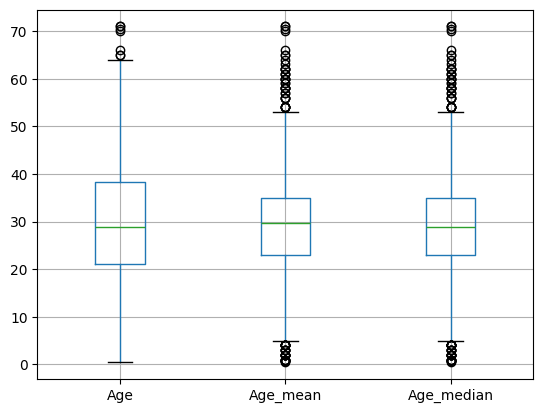

In [32]:
X_train[['Age','Age_mean','Age_median']].boxplot()

<Axes: >

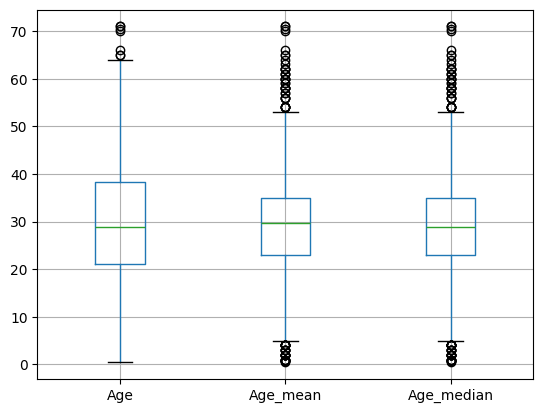

In [33]:
X_train[['Age','Age_mean','Age_median']].boxplot()

* These two many outlers arise due to imputing with mean, as nan data was more than 5% in both columns.

# Using Sklearn:

In [34]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [36]:
imputer1 = SimpleImputer(strategy = 'median')
imputer2 = SimpleImputer(strategy = 'mean')# Creating objects of class

In [37]:
#Applying transformation:
trf = ColumnTransformer([
    ('first',imputer1,['Age']),
    ('second',imputer2,['Fare'])
],remainder='passthrough')

In [38]:
trf.fit(X_train)

/usr/local/lib/python3.11/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('first', SimpleImputer(strategy='median'),
                                 ['Age']),
                                ('second', SimpleImputer(), ['Fare'])])

In [40]:
trf.named_transformers_['first'].statistics_

array([28.75])

In [41]:
trf.named_transformers_['second'].statistics_

array([46.86382946])

In [43]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [45]:
X_train

array([[ 40.        ,  27.7208    ,   0.        ],
       [  4.        ,  16.7       ,   2.        ],
       [ 47.        ,  46.86382946,   0.        ],
       ...,
       [ 71.        ,  49.5042    ,   0.        ],
       [ 28.75      , 221.7792    ,   0.        ],
       [ 28.75      ,  25.925     ,   0.        ]])

# **Arbitrary Value Imputation**

* Replace value with something like :"missing"
* In numerical case, some value like 0, -1 , 99 etc

**Baenefits**:
* Easy to apply.


**Cons**
* Pdf graph distorts.
* variance changes
* Covariance also changes

**Use when:**
* data is **not** missing at random.

In [47]:
X_train = pd.DataFrame(X_train, columns=['Age','Fare','Family']) # Convert X_train back to DataFrame
X_test = pd.DataFrame(X_test, columns=['Age','Fare','Family']) # Convert X_test back to DataFrame

X_train['Age_99']= X_train['Age'].fillna(99)
X_train['Age_minus1']= X_train['Age'].fillna(-1)

X_train['Fare_999']= X_train['Fare'].fillna(999)
X_train['Fare_minus1']= X_train['Fare'].fillna(-1)

In [ ]:
#Check values

In [ ]:
# Plot graphs to determing distributions

In [ ]:
#analyze covariance

In [48]:
#Then trai-test split
#create two imputers
#Apply column transforme
# fit on train data
#Then apply transform on both

# **End of Distribution Imputation**
It is an extension of arbitrary value imputation.

Actually the problem lies in selecting the arbitrary constant, so here we take the end value of our distribution
* If symmetric : mean + 3sigma / mean - 3 sigma
* If skewed : IQR proximity rule : Q1 - 1.5 IQR / Q3 + 1.5IQR

Same pros and cons like above

**Use When** : data is not MCAR